##MNE Library installation

In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 77.0 MB/s eta 0:00:00


In [ ]:
import mne
from google.colab import files

##EDF File

##EDF File Import

In [ ]:
uploaded = files.upload()

Saving aaaaatvr_s005_t000.edf to aaaaatvr_s005_t000.edf


## EDF File information

Loaded file: aaaaatvr_s005_t000.edf
Extracting EDF parameters from aaaaatvr_s005_t000.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 77055  =      0.000 ...   300.996 secs...

Original channels:
['EEG FP1-REF', 'EEG FP2-REF', 'EEG F3-REF', 'EEG F4-REF', 'EEG C3-REF', 'EEG C4-REF', 'EEG P3-REF', 'EEG P4-REF', 'EEG O1-REF', 'EEG O2-REF', 'EEG F7-REF', 'EEG F8-REF', 'EEG T3-REF', 'EEG T4-REF', 'EEG T5-REF', 'EEG T6-REF', 'EEG T1-REF', 'EEG T2-REF', 'EEG FZ-REF', 'EEG CZ-REF', 'EEG PZ-REF', 'EEG EKG1-REF', 'EEG LOC-REF', 'EEG ROC-REF', 'EEG A1-REF', 'EEG A2-REF', 'IBI', 'BURSTS', 'SUPPR']

Sampling frequency: 256.0
Using matplotlib as 2D backend.


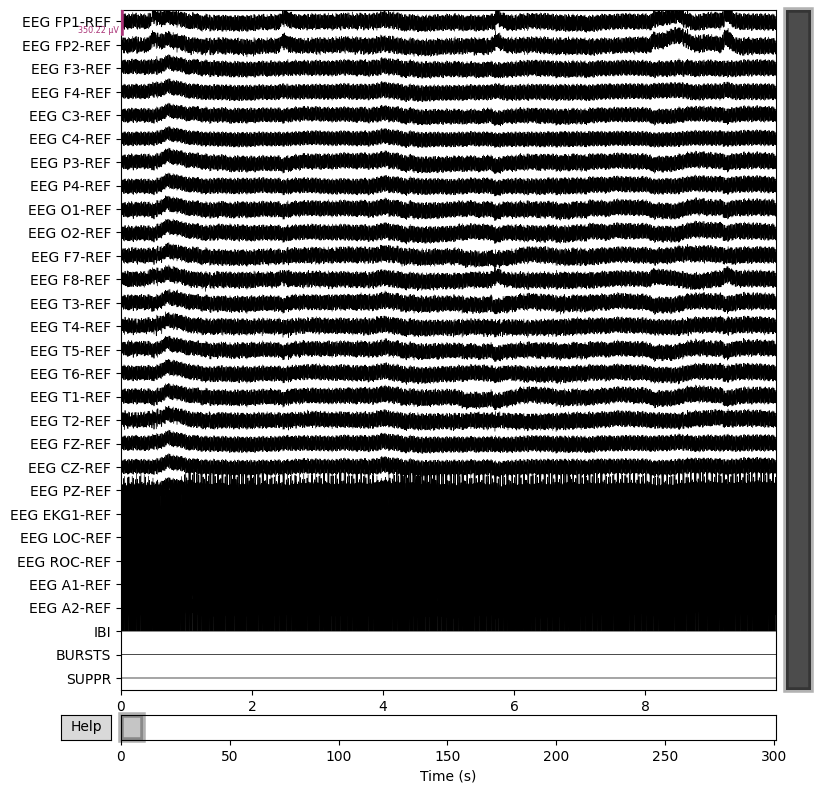

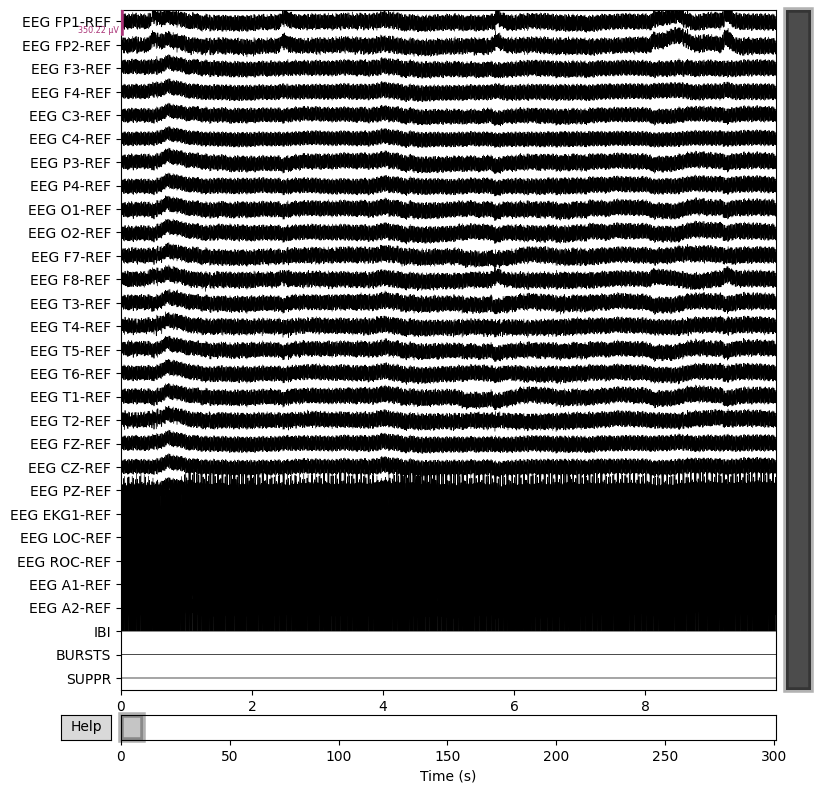

In [ ]:
edf_filename = list(uploaded.keys())[0]

print("Loaded file:", edf_filename)

raw = mne.io.read_raw_edf(edf_filename, preload=True)

print("\nOriginal channels:")
print(raw.ch_names)

print("\nSampling frequency:", raw.info['sfreq'])
# plotting the EEG Channels using Averaged reference montage
raw.plot(
    duration=10,
    n_channels=32,
    title="Original AR Montage",
    scalings="auto"
)

In [ ]:
for i, ch in enumerate(raw.ch_names):
    print(i, ch)

0 EEG FP1-REF
1 EEG FP2-REF
2 EEG F3-REF
3 EEG F4-REF
4 EEG C3-REF
5 EEG C4-REF
6 EEG P3-REF
7 EEG P4-REF
8 EEG O1-REF
9 EEG O2-REF
10 EEG F7-REF
11 EEG F8-REF
12 EEG T3-REF
13 EEG T4-REF
14 EEG T5-REF
15 EEG T6-REF
16 EEG T1-REF
17 EEG T2-REF
18 EEG FZ-REF
19 EEG CZ-REF
20 EEG PZ-REF
21 EEG EKG1-REF
22 EEG LOC-REF
23 EEG ROC-REF
24 EEG A1-REF
25 EEG A2-REF
26 IBI
27 BURSTS
28 SUPPR


##Clean Channel names

In [ ]:
raw.rename_channels(lambda x: x.replace("EEG ", "").replace("-REF", ""))

<RawEDF | aaaaatvr_s005_t000.edf, 29 x 77056 (301.0 s), ~17.1 MiB, data loaded>

##TCP channels mapping

In [ ]:
tcp_pairs = [
    ("FP1","F7"),
    ("F7","T3"),
    ("T3","T5"),
    ("T5","O1"),
    ("FP2","F8"),
    ("F8","T4"),
    ("T4","T6"),
    ("T6","O2"),
    ("A1","T3"),
    ("T3","C3"),
    ("C3","CZ"),
    ("CZ","C4"),
    ("C4","T4"),
    ("T4","A2"),
    ("FP1","F3"),
    ("F3","C3"),
    ("C3","P3"),
    ("P3","O1"),
    ("FP2","F4"),
    ("F4","C4"),
    ("C4","P4"),
    ("P4","O2"),
]

# AR to TCP conversion

In [ ]:
import numpy as np

tcp_data = []
tcp_names = []

for a, b in tcp_pairs:
    if a in raw.ch_names and b in raw.ch_names:
        data = raw.get_data(picks=a) - raw.get_data(picks=b)
        tcp_data.append(data)
        tcp_names.append(f"{a}-{b}")

tcp_data = np.vstack(tcp_data)

info = mne.create_info(tcp_names, raw.info['sfreq'], ch_types='eeg')
raw_tcp = mne.io.RawArray(tcp_data, info)

Creating RawArray with float64 data, n_channels=22, n_times=77056
    Range : 0 ... 77055 =      0.000 ...   300.996 secs
Ready.


['FP1-F7', 'F7-T3', 'T3-T5', 'T5-O1', 'FP2-F8', 'F8-T4', 'T4-T6', 'T6-O2', 'A1-T3', 'T3-C3', 'C3-CZ', 'CZ-C4', 'C4-T4', 'T4-A2', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2']


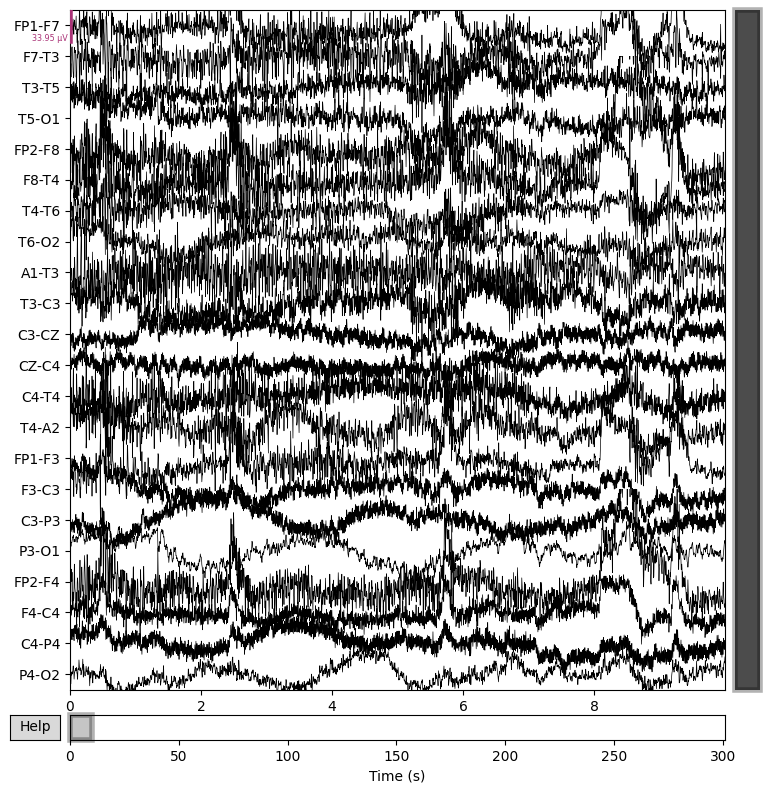

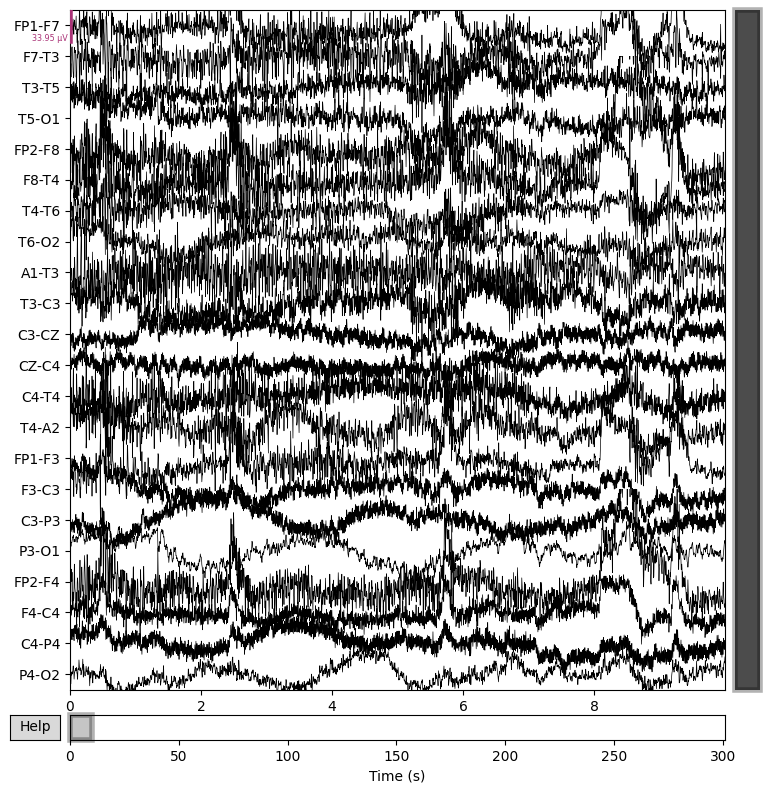

In [ ]:
#Verifying conversion
print(raw_tcp.ch_names)
raw_tcp.plot(duration=10, n_channels=22, scalings="auto")

In [ ]:
len(raw_tcp.ch_names) == 22

True

In [ ]:
#current sampling Frequency
print(raw_tcp.info['sfreq'])

256.0


## Resampling to 250 Hz

In [ ]:
raw_tcp.resample(250)

<RawArray | 22 x 75250 (301.0 s), ~12.7 MiB, data loaded>

In [ ]:
#Verifying that resampling worked
print(raw_tcp.info['sfreq'])

250.0


## Filtering the TCP signal

In [ ]:
# Copy TCP signal before filtering
tcp_filtered = raw_tcp.copy()

# Band-pass filter: 0.5–40 Hz
tcp_filtered.filter(
    l_freq=0.5,
    h_freq=40,
    fir_design='firwin'
)

# Notch filter at 50 Hz (power line noise)
tcp_filtered.notch_filter(
    freqs=50,
    fir_design='firwin'
)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (6.604 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband e

<RawArray | 22 x 75250 (301.0 s), ~12.7 MiB, data loaded>

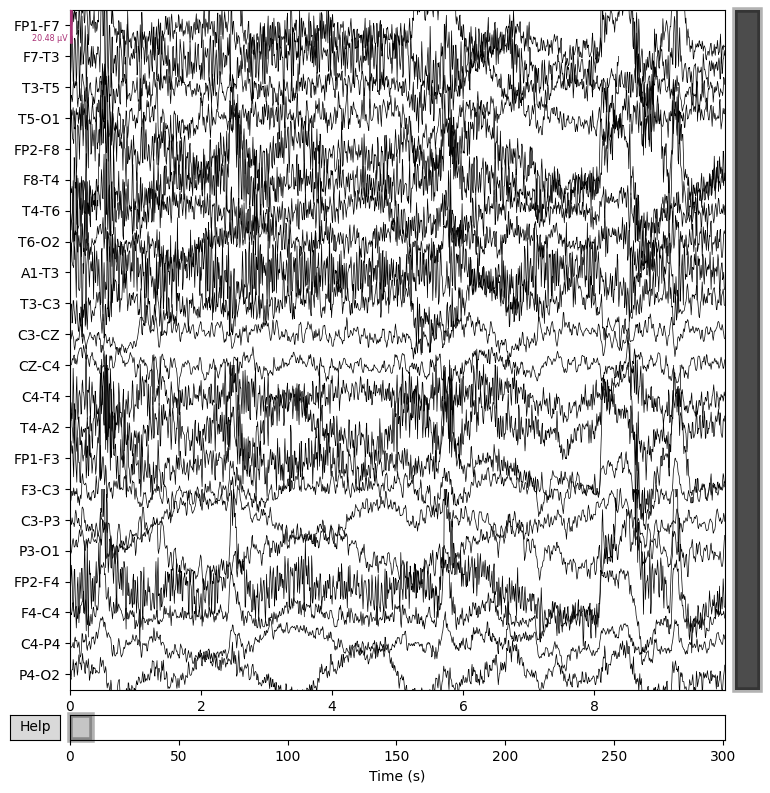

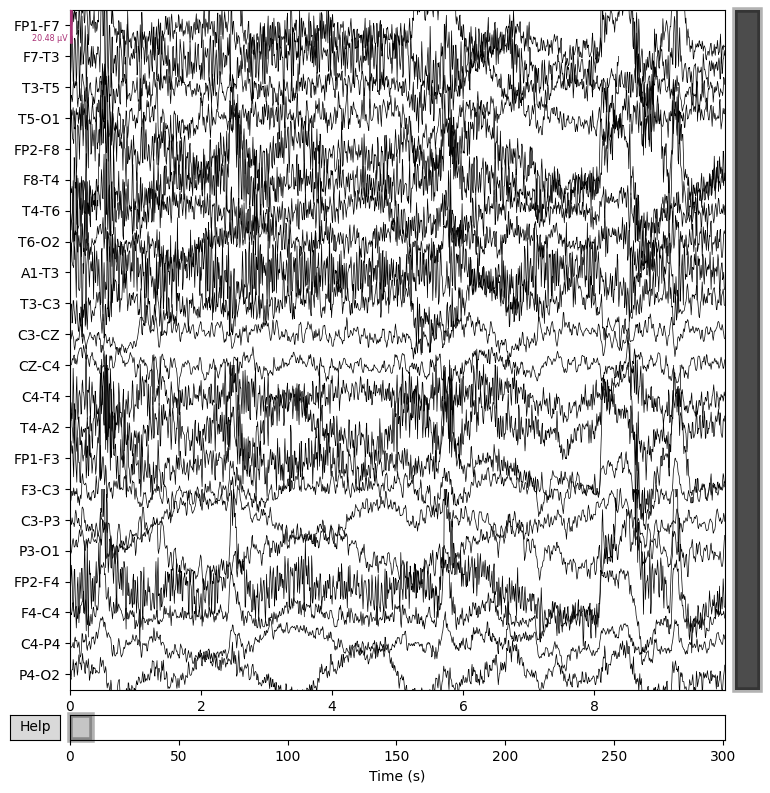

In [ ]:
tcp_filtered.plot(
    duration=10,
    n_channels=22,
    title="TCP Montage (Filtered for Visualization)",
    scalings='auto'
)

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


/tmp/ipython-input-1744755194.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  tcp_filtered.plot_psd(fmax=60)


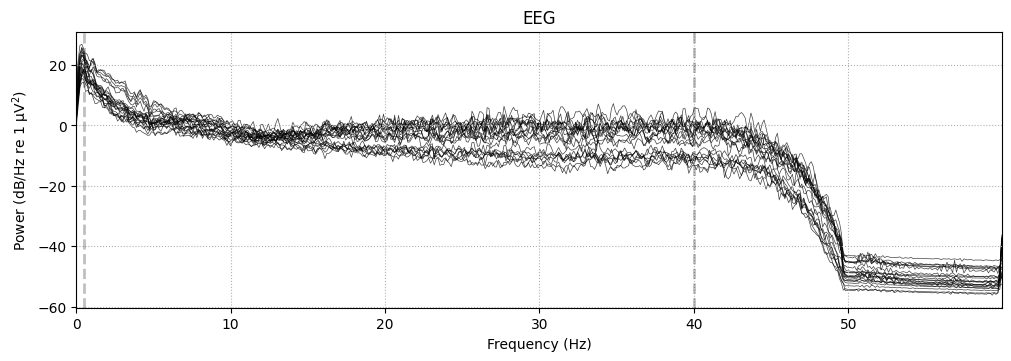

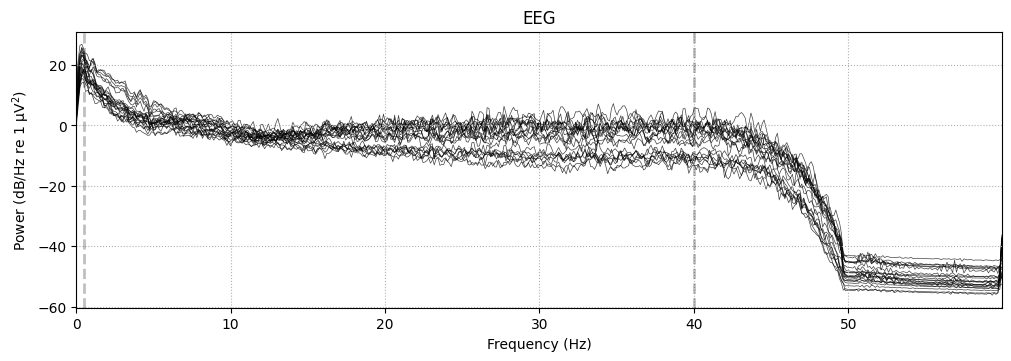

In [ ]:
#PSD plot to check if filtering worked
tcp_filtered.plot_psd(fmax=60)

## Windowing

In [ ]:
import numpy as np
import mne

# --- 1. Parameters ---
window_sec = 10                # window size in seconds
sfreq = int(tcp_filtered.info['sfreq']) # sampling rate (250 Hz)
window_samples = window_sec * sfreq
overlap = 0.5                   # 50% overlap
step = int(window_samples * (1 - overlap))  # step size between windows

# --- 2. Get data from MNE Raw object ---
# This returns shape: (n_channels, n_times)
eeg_data = tcp_filtered.get_data()
n_channels, n_times = eeg_data.shape
print(f"EEG shape: {n_channels} channels, {n_times} time points")

# --- 3. Segment into overlapping windows ---
windows = []
start = 0
while start + window_samples <= n_times:
    end = start + window_samples
    window = eeg_data[:, start:end]  # shape: (22, 2500)
    windows.append(window)
    start += step  # move start by step size

# Convert list to NumPy array
windows = np.array(windows)  # shape: (num_windows, n_channels, window_samples)
print(f"Windows array shape: {windows.shape}")

EEG shape: 22 channels, 75250 time points
Windows array shape: (59, 22, 2500)


### Binary labeling

In [ ]:
import pandas as pd
import numpy as np

# --- 1. Load annotation file ---
annotations = pd.read_csv(
    'aaaaatvr_s005_t000.csv_bi',
    comment='#'   # skip metadata lines
)

# --- 2. Keep ONLY seizure events ---
seiz_annotations = annotations[annotations['label'] == 'seiz']

# --- 3. Extract seizure intervals (seconds) ---
seiz_events = seiz_annotations[['start_time', 'stop_time']].values

# Safety message (useful for debugging)
if len(seiz_events) == 0:
    print("No seizure events in this session")

# --- 4. Assign labels to windows ---
labels = []
num_windows = windows.shape[0]

for i in range(num_windows):
    window_start = (i * step) / sfreq
    window_end = window_start + window_sec

    window_label = 0  # default background

    # Check overlap with seizure intervals
    for seiz_start, seiz_stop in seiz_events:
        if (window_start < seiz_stop) and (window_end > seiz_start):
            window_label = 1
            break

    labels.append(window_label)

labels = np.array(labels)

# --- 5. Verification ---
print("Labels shape:", labels.shape)
print("Seizure windows:", np.sum(labels == 1))
print("Background windows:", np.sum(labels == 0))

No seizure events in this session
Labels shape: (59,)
Seizure windows: 0
Background windows: 59


## Verifying labels

In [ ]:
for i in range(len(labels)):
    window_start = (i * step) / sfreq
    window_end = window_start + window_sec

    print(f"Window {i:3d}: {window_start:7.2f}s → {window_end:7.2f}s | Label: {labels[i]}")


Window   0:    0.00s →   10.00s | Label: 0
Window   1:    5.00s →   15.00s | Label: 0
Window   2:   10.00s →   20.00s | Label: 0
Window   3:   15.00s →   25.00s | Label: 0
Window   4:   20.00s →   30.00s | Label: 0
Window   5:   25.00s →   35.00s | Label: 0
Window   6:   30.00s →   40.00s | Label: 0
Window   7:   35.00s →   45.00s | Label: 0
Window   8:   40.00s →   50.00s | Label: 0
Window   9:   45.00s →   55.00s | Label: 0
Window  10:   50.00s →   60.00s | Label: 0
Window  11:   55.00s →   65.00s | Label: 0
Window  12:   60.00s →   70.00s | Label: 0
Window  13:   65.00s →   75.00s | Label: 0
Window  14:   70.00s →   80.00s | Label: 0
Window  15:   75.00s →   85.00s | Label: 0
Window  16:   80.00s →   90.00s | Label: 0
Window  17:   85.00s →   95.00s | Label: 0
Window  18:   90.00s →  100.00s | Label: 0
Window  19:   95.00s →  105.00s | Label: 0
Window  20:  100.00s →  110.00s | Label: 0
Window  21:  105.00s →  115.00s | Label: 0
Window  22:  110.00s →  120.00s | Label: 0
Window  23:

## Normalization per window

In [ ]:
#This normalizes each window independently so mean ≈ 0 and std ≈ 1.

import numpy as np

# windows shape: (59, 22, 2500)

windows_normalized = (
    windows - np.mean(windows, axis=(1, 2), keepdims=True)
) / (
    np.std(windows, axis=(1, 2), keepdims=True) + 1e-8
)

windows_normalized.shape
# (59, 22, 2500) for this file


(59, 22, 2500)

##Normalization Verification codes

In [ ]:
# Check first 5 windows
for i in range(5):
    mean = np.mean(windows_normalized[i])
    std = np.std(windows_normalized[i])

    print(f"Window {i}: mean = {mean:.5f}, std = {std:.5f}")

Window 0: mean = 0.00000, std = 0.99927
Window 1: mean = -0.00000, std = 0.99918
Window 2: mean = -0.00000, std = 0.99930
Window 3: mean = 0.00000, std = 0.99956
Window 4: mean = 0.00000, std = 0.99954


In [ ]:
#this snippet verifies Normalization for the entire windows in this file
print("Overall mean:", np.mean(windows_normalized))
print("Overall std:", np.std(windows_normalized))

Overall mean: -6.568962117967028e-19
Overall std: 0.9990088700789217


In [ ]:
import numpy as np

# mean and std per window per channel
means = windows_normalized.mean(axis=2)
stds = windows_normalized.std(axis=2)

print("Mean range:", means.min(), means.max())
print("Std range:", stds.min(), stds.max())

Mean range: -0.24042739811324804 0.19676747277640347
Std range: 0.30560158864174547 2.343763948207689


In [ ]:
print("Shape:", windows_normalized.shape)
assert windows_normalized.shape == (59, 22, 2500)

Shape: (59, 22, 2500)


In [ ]:
print("NaN count:", np.isnan(windows_normalized).sum())
print("Inf count:", np.isinf(windows_normalized).sum())

NaN count: 0
Inf count: 0


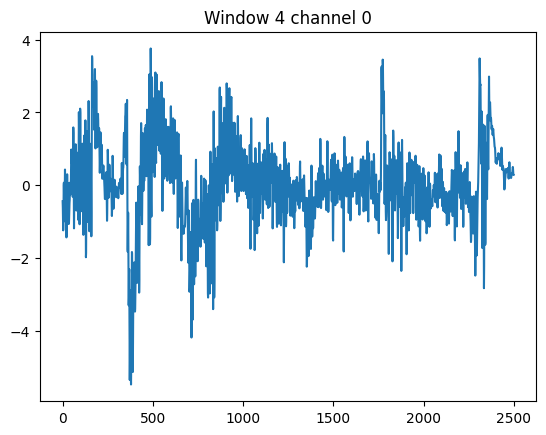

In [ ]:
import matplotlib.pyplot as plt
import random

w = random.randint(0, windows_normalized.shape[0])
plt.plot(windows_normalized[w, 0])
plt.title(f"Window {w} channel 0")
plt.show()
# the resulted random window should be centred about zero
# it should contain reasonable amplitudes
# seizure patterns should be preserved

In [ ]:
print("Windows:", windows_normalized.shape[0])
print("Labels:", labels.shape[0])
assert windows_normalized.shape[0] == labels.shape[0]

Windows: 59
Labels: 59


## Saving windows + labels in a single .npz file per EDF file

In [ ]:
np.savez_compressed(
    "test_recording_windows_labels.npz",
    windows=windows_normalized.astype(np.float32),
    labels=labels.astype(np.int8)
)

In [ ]:
data = np.load("test_recording_windows_labels.npz")

print(data["windows"].shape)
print(data["labels"].shape)

(59, 22, 2500)
(59,)
